# Preprocessing

In [ ]:
import requests
from google.cloud import storage
from google.colab import auth
from tqdm.auto import tqdm
import os
from google.colab import userdata
import json

# --- 1. Securely get the key from Colab Secrets ---
key_string = userdata.get('GCP_KEY')
key_data = json.loads(key_string)

# --- 2. Authenticate gsutil ---
with open('temp_key.json', 'w') as f:
    json.dump(key_data, f)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = 'temp_key.json'
!gcloud auth activate-service-account --key-file=temp_key.json

# --- 2. Configuration Variables ---
BUCKET_NAME = "asvspoof-la-data-bucket"

DOWNLOAD_URL = "https://zenodo.org/records/14498691/files/flac_E_ae.tar?download=1"

DESTINATION_BLOB_NAME = "ASVspoof5/flac_E_ae.tar"

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]


In [ ]:
import os
import tarfile
import pandas as pd
import tensorflow as tf
import numpy as np
from tqdm.auto import tqdm

# --- Configuration ---
GCS_TAR_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/flac_E_ae.tar"
LOCAL_TAR_PATH = "/content/flac_E_ae.tar"

EXTRACT_PATH = "/content/flac_E_eval"

PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("✅ Configuration set.")

✅ Configuration set.


In [ ]:
!sudo pip3 install --no-cache-dir -U crcmod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 63.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for crcmod: filename=crcmod-1.7-cp312-cp312-linux_x86_64.whl size=31832 sha256=f60e82ca34b9eceeaab79af48da44aec295fcaad891bd9a05e26a6376e448f4a
  Stored in directory: /tmp/pip-ephem-wheel-cache-cthcm198/wheels/76/08/0b/caa8b1380122cbfe6a03eaccbec0f63c67e619af4e30ca5e2a
Successfully built crcmod


In [ ]:
# --- Extract Audio Files ---

# 1. Check if we need to copy from GCS
if not os.path.exists(LOCAL_TAR_PATH):
    print(f"Copying {GCS_TAR_PATH} to local disk...")
    !gsutil cp {GCS_TAR_PATH} {LOCAL_TAR_PATH}

# 2. Extract the files
if not os.path.exists(EXTRACT_PATH):
    print(f"Extracting {LOCAL_TAR_PATH}...")
    with tarfile.open(LOCAL_TAR_PATH) as tar:
        tar.extractall(path="/content")
    print("✅ Extraction complete.")
else:
    print("✅ Files already extracted.")

# 3. Verify extraction
extracted_files = os.listdir(EXTRACT_PATH)
print(f"Found {len(extracted_files)} files in {EXTRACT_PATH}")
print(f"Example file: {extracted_files[0]}")

Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar to local disk...
Copying gs://asvspoof-la-data-bucket/ASVspoof5/flac_E_ae.tar...
- [1 files][  7.9 GiB/  7.9 GiB]   73.5 MiB/s                                   
Operation completed over 1 objects/7.9 GiB.                                      
Extracting /content/flac_E_ae.tar...


/tmp/ipython-input-1070124683.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content")


✅ Extraction complete.
Found 68188 files in /content/flac_E_eval
Example file: E_0004565637.flac


In [ ]:
import pandas as pd
import os

# --- Configuration ---
EXTRACT_PATH = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"

print("Loading protocol...")

column_names = [
    'SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC',
    'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP'
]

# 1. Load Protocol
df = pd.read_csv(
    PROTOCOL_PATH,
    sep=' ',
    names=column_names,
    storage_options={'token': 'temp_key.json'}
)

# 2. Identify available files
extracted_files = os.listdir(EXTRACT_PATH)
available_files_set = set([f.replace('.flac', '') for f in extracted_files])

# 3. Filter Protocol to match available files
test_df = df[df['AUDIO_FILE_NAME'].isin(available_files_set)].copy()

test_df['LABEL'] = test_df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

print(f"✅ Protocol Loaded.")
print(f"   Total files to test: {len(test_df)}")
print(f"   Breakdown: {test_df['KEY'].value_counts().to_dict()}")

Loading protocol...
✅ Protocol Loaded.
   Total files to test: 68188
   Breakdown: {'spoof': 54194, 'bonafide': 13994}


# Training

In [ ]:
import os
import requests
import tarfile
import time
from google.cloud import storage
from google.colab import auth
from tqdm.auto import tqdm

# --- 1. Configuration ---
BUCKET_NAME = "asvspoof-la-data-bucket"

DOWNLOAD_URL = "https://zenodo.org/records/14498691/files/flac_T_aa.tar?download=1"
GCS_BLOB_NAME = "ASVspoof5/flac_E_aa.tar"
LOCAL_TAR_PATH = "/content/flac_E_aa.tar"
EXTRACT_PATH = "/content/flac_E_eval"

In [ ]:
# A. Setup GCS Client
storage_client = storage.Client()
bucket = storage_client.bucket(BUCKET_NAME)
blob = bucket.blob(GCS_BLOB_NAME)

# B. Check if file already exists in GCS
if not blob.exists():
    print(f"🌊 Downloading to GCS: gs://{BUCKET_NAME}/{GCS_BLOB_NAME}")
    print("   (This streams directly to storage to save RAM...)")

    try:
        with requests.get(DOWNLOAD_URL, stream=True) as r:
            r.raise_for_status()
            total_size = int(r.headers.get('content-length', 0))

            with blob.open("wb", ignore_flush=True) as f:
                with tqdm(total=total_size, unit='B', unit_scale=True, desc="GCS Upload") as pbar:
                    for chunk in r.iter_content(chunk_size=1024 * 1024 * 5):
                        if chunk:
                            f.write(chunk)
                            pbar.update(len(chunk))
        print("✅ Download to GCS complete.")
    except Exception as e:
        print(f"❌ Error downloading to GCS: {e}")
else:
    print(f"✅ File already exists in GCS: gs://{BUCKET_NAME}/{GCS_BLOB_NAME}")

🌊 Downloading to GCS: gs://asvspoof-la-data-bucket/ASVspoof5/flac_T_aa.tar
   (This streams directly to storage to save RAM...)


GCS Upload:   0%|          | 0.00/7.52G [00:00<?, ?B/s]

✅ Download to GCS complete.


In [ ]:
# C. Copy to Local Disk
if not os.path.exists(LOCAL_TAR_PATH):
    print(f"⬇️ Copying from GCS to local disk...")
    exit_code = os.system(f"gsutil cp gs://{BUCKET_NAME}/{GCS_BLOB_NAME} {LOCAL_TAR_PATH}")
    if exit_code != 0:
        raise Exception("❌ gsutil copy failed.")
else:
    print("✅ Local tar file already exists.")

✅ Local tar file already exists.


In [ ]:
!rm -rf /content/flac_E_eval

In [ ]:
# D. Extract
if not os.path.exists(EXTRACT_PATH):
    print(f"📦 Extracting to {EXTRACT_PATH} (this takes ~60s)...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    exit_code = os.system(f"tar -xf {LOCAL_TAR_PATH} -C '/content'")

    if exit_code == 0:
        print("✅ Extraction complete!")
        num_files = len(os.listdir(EXTRACT_PATH))
        print(f"   Found {num_files} files ready for training.")
    else:
        print("❌ Error during extraction.")
else:
    print(f"✅ Files already extracted in {EXTRACT_PATH}")

📦 Extracting to /content/flac_E_eval (this takes ~60s)...
✅ Extraction complete!
   Found 68188 files ready for training.


In [ ]:
num_files = len(os.listdir(EXTRACT_PATH))
print(f"   Found {num_files} files ready for training.")

   Found 68188 files ready for training.


In [ ]:
import pandas as pd
import tensorflow as tf
import os
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers, models, Input

# --- Configuration ---
DATA_DIR = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"
BATCH_SIZE = 32
EPOCHS = 50

# --- 1. Load Protocol ---
print("Loading Protocol...")
cols = ['SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC', 'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP']

try:
    df = pd.read_csv(PROTOCOL_PATH, sep=' ', names=cols, storage_options={'token': 'temp_key.json'})
except:
    df = pd.read_csv("ASVspoof5.eval.track_1.tsv", sep=' ', names=cols)

# Filter for files on disk
available_files = set([f.replace('.flac', '') for f in os.listdir(DATA_DIR)])
df = df[df['AUDIO_FILE_NAME'].isin(available_files)].copy()
df['LABEL'] = df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

# --- 2. Calculate Class Weights ---
labels = df['LABEL'].values
class_weights_arr = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights_arr))

print(f"✅ Data Ready: {len(df)} files")
print(f"⚖️ Class Weights: {class_weights}")

Loading Protocol...
✅ Data Ready: 68188 files
⚖️ Class Weights: {0: np.float64(2.405899371956813), 1: np.float64(0.6311716681785364)}


In [ ]:
# --- 3. Data Pipeline ---
def load_audio(file_path):
    if isinstance(file_path, bytes): file_path = file_path.decode('utf-8')
    audio, _ = sf.read(file_path)
    return audio.astype(np.float32)

def create_spectrogram(audio_tensor):
    if len(audio_tensor.shape) > 1: audio_tensor = tf.squeeze(audio_tensor, axis=-1)
    stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
    spectrograms = tf.abs(stfts)
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
    mel_spectrograms = tf.tensordot(spectrograms, linear_to_mel_weight_matrix, 1)
    mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))
    return tf.math.log(mel_spectrograms + 1e-6)

def process_path(file_path, label):
    audio = tf.numpy_function(load_audio, [file_path], tf.float32)
    audio.set_shape([None])
    spec = create_spectrogram(audio)
    spec.set_shape((None, 128))
    return spec, label

In [ ]:
# Create Full Dataset
file_paths = [os.path.join(DATA_DIR, f + ".flac") for f in df['AUDIO_FILE_NAME'].values]
targets = df['LABEL'].values.astype('int64')

full_ds = tf.data.Dataset.from_tensor_slices((file_paths, targets))
full_ds = full_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

full_ds = full_ds.shuffle(5000, seed=42).padded_batch(BATCH_SIZE, padded_shapes=([None, 128], []))

In [ ]:
# --- 4. The 3-Way Split (70 / 15 / 15) ---
total_batches = len(df) // BATCH_SIZE
train_batches = int(total_batches * 0.70)
val_batches = int(total_batches * 0.15)
test_batches = total_batches - train_batches - val_batches

train_ds = full_ds.take(train_batches).prefetch(tf.data.AUTOTUNE)
remaining = full_ds.skip(train_batches)
val_ds = remaining.take(val_batches).prefetch(tf.data.AUTOTUNE)
test_ds = remaining.skip(val_batches).prefetch(tf.data.AUTOTUNE)

print(f"✂️ Splits Created:")
print(f"   Train: {train_batches} batches (~{train_batches*32} files)")
print(f"   Val:   {val_batches} batches (~{val_batches*32} files)")
print(f"   Test:  {test_batches} batches (~{test_batches*32} files)")

✂️ Splits Created:
   Train: 1491 batches (~47712 files)
   Val:   319 batches (~10208 files)
   Test:  320 batches (~10240 files)


In [ ]:
# --- 5. Build Model (GRU) ---
def build_model():
    model = models.Sequential([
        Input(shape=(None, 128)),
        layers.Masking(mask_value=0.0),
        layers.Bidirectional(layers.GRU(128, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.GRU(64, return_sequences=False)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model()

In [ ]:
# --- 6. Train ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1, mode='min'),
    ModelCheckpoint(
        f"gs://{BUCKET_NAME}/models/best_model_eval_df.keras",
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\n🚀 Starting Training...")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weights
)

print("\n📝 Running Final Exam on Held-Out Test Set...")
# Evaluate returns [loss, accuracy, auc]
results = model.evaluate(test_ds, verbose=1)

print("\n" + "="*40)
print("🏆 FINAL PRODUCT PERFORMANCE")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test AUC:      {results[2]:.4f}")
print("="*40)

if results[2] > 0.90:
    print("✅ Ready for production fine-tuning!")
else:
    print("⚠️ Model needs improvement before fine-tuning.")


🚀 Starting Training...
Epoch 1/50
1490/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6483 - auc: 0.6590 - loss: 0.6444
Epoch 1: val_auc improved from -inf to 0.81891, saving model to gs://asvspoof-la-data-bucket/models/best_model_eval_df.keras
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 159s 99ms/step - accuracy: 0.6483 - auc: 0.6591 - loss: 0.6444 - val_accuracy: 0.6968 - val_auc: 0.8189 - val_loss: 0.5347
Epoch 2/50
1490/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7235 - auc: 0.8198 - loss: 0.5094
Epoch 2: val_auc improved from 0.81891 to 0.86337, saving model to gs://asvspoof-la-data-bucket/models/best_model_eval_df.keras
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 150s 98ms/step - accuracy: 0.7235 - auc: 0.8198 - loss: 0.5094 - val_accuracy: 0.8047 - val_auc: 0.8634 - val_loss: 0.4002
Epoch 3/50
1490/1491 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7854 - auc: 0.8783 - loss: 0.4298
Epoch 3: val_auc improved from 0.86337 to 0.92870, saving model to gs://asvspoof-la-data-bucket/models/bes

# Evaluation

Loading Protocol to recreate Test Split...
✅ Isolated Test Set: 10229 files (The 'Final Exam')
Loading model from gs://asvspoof-la-data-bucket/models/best_model_eval_df.keras...
🚀 Running Inference on Test Split...


  0%|          | 0/10229 [00:00<?, ?it/s]


🏆 FINAL TEST RESULTS
Accuracy: 90.03%
Recall (Caught Spoofs): 88.62%
FPR (False Alarms):     4.58%
--------------------------------------------------
CONFUSION MATRIX:
              Pred Real | Pred Spoof
Actual Real | 2021      | 97       
Actual Spoof| 923       | 7188     


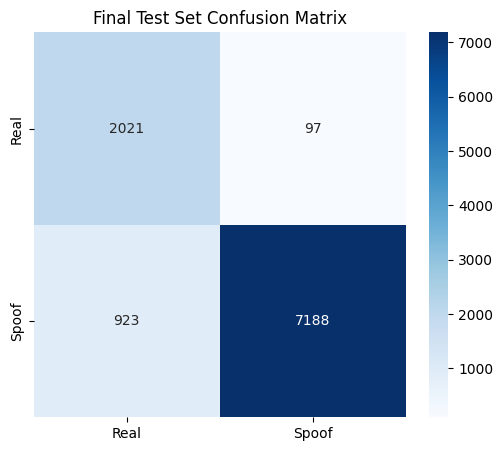


🕵️ FALSE NEGATIVE BREAKDOWN (Missed Spoofs)
Total Missed Spoofs: 923
Attack Code     | Count    | % of Failures
--------------------------------------------------
A28             | 218      | 23.6%
A17             | 163      | 17.7%
A19             | 160      | 17.3%
A26             | 92       | 10.0%
A29             | 60       | 6.5%
A22             | 45       | 4.9%
A25             | 43       | 4.7%
A21             | 33       | 3.6%
A31             | 27       | 2.9%
A24             | 25       | 2.7%
A27             | 18       | 2.0%
A30             | 15       | 1.6%
A32             | 10       | 1.1%
A20             | 8        | 0.9%
A18             | 3        | 0.3%
A23             | 3        | 0.3%
--------------------------------------------------
KEY:
• A17/A18: Zero-Shot / Voice Conversion (Hardest)
• A12: Text-to-Speech
• A19: Noisy/Replay Attacks


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from tqdm.auto import tqdm
import soundfile as sf

# --- Configuration ---
DATA_DIR = "/content/flac_E_eval"
PROTOCOL_PATH = f"gs://{BUCKET_NAME}/ASVspoof5/protocols/ASVspoof5.eval.track_1.tsv"
MODEL_PATH = f"gs://{BUCKET_NAME}/models/best_model_eval_df.keras"

print("Loading Protocol to recreate Test Split...")
cols = ['SPEAKER_ID', 'AUDIO_FILE_NAME', 'SPEAKER_GENDER', 'CODEC', 'CODEC_Q', 'CODEC_SEED', 'ATTACK_TAG', 'ATTACK_LABEL', 'KEY', 'TMP']

try:
    df = pd.read_csv(PROTOCOL_PATH, sep=' ', names=cols, storage_options={'token': 'temp_key.json'})
except:
    df = pd.read_csv("ASVspoof5.eval.track_1.tsv", sep=' ', names=cols)

# Filter for files on disk
available_files = set([f.replace('.flac', '') for f in os.listdir(DATA_DIR)])
df = df[df['AUDIO_FILE_NAME'].isin(available_files)].copy()
df['LABEL'] = df['KEY'].apply(lambda x: 1 if x == 'spoof' else 0)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calculate Split Indices (70 / 15 / 15)
n_total = len(df)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)
n_test = n_total - n_train - n_val

test_df = df.tail(n_test).copy()
print(f"✅ Isolated Test Set: {len(test_df)} files (The 'Final Exam')")

# --- 2. Load Model ---
print(f"Loading model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

# --- 3. Helper Functions ---
def load_audio_test(file_path):
    audio, _ = sf.read(file_path)
    return audio.astype(np.float32)

def create_spectrogram_test(audio):
    audio_tensor = tf.convert_to_tensor(audio)
    if len(audio_tensor.shape) > 1:
        audio_tensor = tf.squeeze(audio_tensor, axis=-1)
    stfts = tf.signal.stft(audio_tensor, frame_length=1024, frame_step=512, fft_length=1024)
    spectrograms = tf.abs(stfts)
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(128, 513, 16000, 20, 4000)
    mel_spectrograms = tf.tensordot(spectrograms, linear_to_mel_weight_matrix, 1)
    mel_spectrograms.set_shape(spectrograms.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))
    log_mel = tf.math.log(mel_spectrograms + 1e-6)
    return log_mel

# --- 4. Run Predictions ---
print("🚀 Running Inference on Test Split...")
y_true = []
y_pred_probs = []
y_pred_classes = []
attack_labels = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(DATA_DIR, row['AUDIO_FILE_NAME'] + ".flac")

    try:
        # Preprocess
        audio = load_audio_test(fpath)
        spec = create_spectrogram_test(audio)
        spec = tf.expand_dims(spec, 0)

        # Predict
        prob = model.predict(spec, verbose=0)[0][0]

        # Store
        y_true.append(row['LABEL'])
        y_pred_probs.append(prob)
        y_pred_classes.append(1 if prob > 0.5 else 0)
        attack_labels.append(row['ATTACK_LABEL'])

    except Exception as e:
        print(f"❌ Skipped {row['AUDIO_FILE_NAME']}: {e}")

# --- 5. Generate Reports ---

# A. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# Metrics
acc = accuracy_score(y_true, y_pred_classes) * 100
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0

print("\n" + "="*50)
print("🏆 FINAL TEST RESULTS")
print("="*50)
print(f"Accuracy: {acc:.2f}%")
print(f"Recall (Caught Spoofs): {recall:.2f}%")
print(f"FPR (False Alarms):     {fpr:.2f}%")
print("-" * 50)
print("CONFUSION MATRIX:")
print(f"              Pred Real | Pred Spoof")
print(f"Actual Real | {tn:<9} | {fp:<9}")
print(f"Actual Spoof| {fn:<9} | {tp:<9}")

# Plot CM
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Spoof'], yticklabels=['Real', 'Spoof'])
plt.title('Final Test Set Confusion Matrix')
plt.show()

# B. False Negative Analysis
print("\n" + "="*50)
print("🕵️ FALSE NEGATIVE BREAKDOWN (Missed Spoofs)")
print("="*50)

# Create results dataframe
res_df = pd.DataFrame({
    'true': y_true,
    'pred': y_pred_classes,
    'prob': y_pred_probs,
    'attack': attack_labels
})

fn_df = res_df[(res_df['true'] == 1) & (res_df['pred'] == 0)]

if len(fn_df) > 0:
    print(f"Total Missed Spoofs: {len(fn_df)}")
    print(f"{'Attack Code':<15} | {'Count':<8} | {'% of Failures'}")
    print("-" * 50)

    counts = fn_df['attack'].value_counts()
    for attack, count in counts.items():
        pct = (count / len(fn_df)) * 100
        print(f"{attack:<15} | {count:<8} | {pct:.1f}%")

    print("-" * 50)
    print("KEY:")
    print("• A17/A18: Zero-Shot / Voice Conversion (Hardest)")
    print("• A12: Text-to-Speech")
    print("• A19: Noisy/Replay Attacks")
else:
    print("🎉 PERFECT SCORE! No spoofs were missed in the test set.")